In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv('Crop_Recommendation.csv')
print("Original dataset shape:",df.shape)
print("original dataset preview:")
df

Original dataset shape: (2200, 8)
original dataset preview:


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [3]:
#remove diplicates
df=df.drop_duplicates()
df=df[(df!=0).all(axis=1)]
df=df.loc[:,(df!=0).any(axis=0)]
print("\n cleaned dataset shape :",df.shape)
print("cleaned dataset preview")
dt = pd.read_csv('cleaned_dataset.csv')
dt




 cleaned dataset shape : (2173, 8)
cleaned dataset preview


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice
...,...,...,...,...,...,...,...,...
2168,107,34,32,26.774637,66.413269,6.780064,177.774507,Coffee
2169,99,15,27,27.417112,56.636362,6.086922,127.924610,Coffee
2170,118,33,30,24.131797,67.225123,6.362608,173.322839,Coffee
2171,117,32,34,26.272418,52.127394,6.758793,127.175293,Coffee


In [4]:

dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2173 entries, 0 to 2172
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2173 non-null   int64  
 1   Phosphorus   2173 non-null   int64  
 2   Potassium    2173 non-null   int64  
 3   Temperature  2173 non-null   float64
 4   Humidity     2173 non-null   float64
 5   pH_Value     2173 non-null   float64
 6   Rainfall     2173 non-null   float64
 7   Crop         2173 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 135.9+ KB


In [5]:

dt.Crop.value_counts()

Crop
Rice           100
Banana         100
Jute           100
Cotton         100
Papaya         100
Muskmelon      100
Watermelon     100
Maize          100
Coffee         100
Blackgram      100
ChickPea       100
Grapes          99
MungBean        99
MothBeans       99
PigeonPeas      99
KidneyBeans     98
Pomegranate     97
Apple           97
Mango           97
Lentil          96
Orange          96
Coconut         96
Name: count, dtype: int64

In [6]:

# Load the dataset
dataset_path = 'cleaned_dataset.csv'
dt = pd.read_csv(dataset_path)

# Split the dataset (80% train, 20% test)
train_dt, test_dt = train_test_split(dt, test_size=0.2, random_state=42)

# Save the datasets
train_dt.to_csv('train_dataset.csv', index=False)
test_dt.to_csv('test_dataset.csv', index=False)

print("Datasets split and saved successfully!")

Datasets split and saved successfully!


In [7]:
train=pd.read_csv('train_dataset.csv')
train

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,99,6,46,28.614751,94.222530,6.396379,28.985742,Muskmelon
1,35,57,25,27.095629,42.262062,8.340398,71.127104,MothBeans
2,99,29,55,29.193787,91.462411,6.660955,26.482403,Muskmelon
3,17,67,18,31.219275,56.468689,5.611511,129.202865,PigeonPeas
4,35,52,15,28.698413,61.147544,9.935091,65.675918,MothBeans
...,...,...,...,...,...,...,...,...
1733,12,6,8,30.848350,92.867737,6.388617,107.414268,Orange
1734,11,36,33,35.990097,52.227805,5.978634,95.371348,Mango
1735,5,32,33,32.323622,52.589677,5.842764,93.367188,Mango
1736,83,25,53,26.491953,80.046782,6.057697,57.727992,Watermelon


In [8]:
test=pd.read_csv('test_dataset.csv')
test

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop
0,47,79,78,17.483954,14.760145,6.609697,65.113656,ChickPea
1,24,30,11,32.395240,94.517685,6.601396,113.253730,Orange
2,78,46,42,23.094996,78.459597,7.095413,155.385153,Jute
3,34,45,21,28.188371,82.606297,6.287380,37.011104,MungBean
4,99,15,27,27.042417,57.279275,6.501157,165.687212,Coffee
...,...,...,...,...,...,...,...,...
430,108,94,47,27.359116,84.546250,6.387431,90.812505,Banana
431,105,30,50,25.299547,81.775276,6.376201,57.041471,Watermelon
432,28,70,21,25.390384,60.498966,7.437374,39.183745,Lentil
433,4,20,41,24.266013,93.797406,6.537043,104.537511,Pomegranate


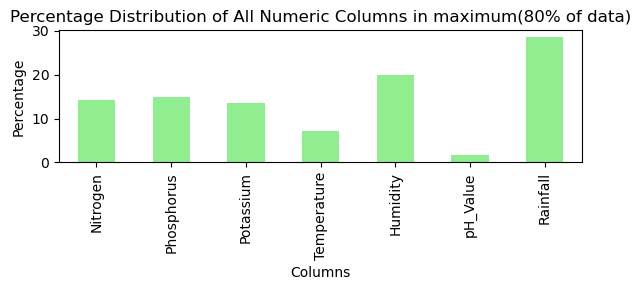

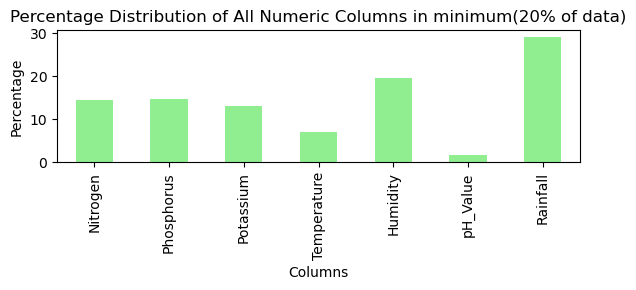

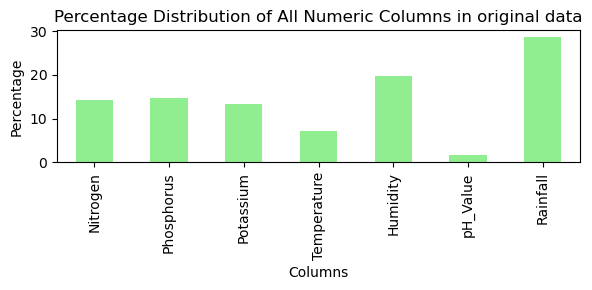

In [9]:

# Visualize the class distribution
plt.figure(figsize=(6, 3))
# Bar chart for all numerical columns as percentages
numeric_columns = train.select_dtypes(include='number').columns
total_sum = train[numeric_columns].sum()
percentage_values = (total_sum / total_sum.sum()) * 100

percentage_values.plot(kind='bar', color='lightgreen')

plt.title('Percentage Distribution of All Numeric Columns in maximum(80% of data)')
plt.ylabel('Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


# Visualize the class distribution
plt.figure(figsize=(6, 3))
# Bar chart for all numerical columns as percentages
numeric_columns = test.select_dtypes(include='number').columns
total_sum = test[numeric_columns].sum()
percentage_values = (total_sum / total_sum.sum()) * 100

percentage_values.plot(kind='bar', color='lightgreen')

plt.title('Percentage Distribution of All Numeric Columns in minimum(20% of data)')
plt.ylabel('Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()

# Visualize the class distribution
plt.figure(figsize=(6, 3))
# Bar chart for all numerical columns as percentages
numeric_columns = df.select_dtypes(include='number').columns
total_sum = df[numeric_columns].sum()
percentage_values = (total_sum / total_sum.sum()) * 100

percentage_values.plot(kind='bar', color='lightgreen')

plt.title('Percentage Distribution of All Numeric Columns in original data')
plt.ylabel('Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()

In [10]:


# Load datasets
train_data = pd.read_csv('train_dataset.csv')

# Encode the target variable (Crop) using LabelEncoder
le = LabelEncoder()
train_data["Crop"] = le.fit_transform(train_data[ "Crop"])

# Split data into training (80%) and testing (20%)
X = train_data.drop("Crop", axis=1)
y = train_data["Crop"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))



# Save the trained model
joblib.dump(model,
'random_forest_crop_model.pkl')

# Optional: Save the label encoder as well (for decoding predictions later)
joblib.dump(le, 'label_encoder.pkl')

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

       Apple       1.00      1.00      1.00        11
      Banana       1.00      1.00      1.00        18
   Blackgram       1.00      1.00      1.00        17
    ChickPea       1.00      1.00      1.00        19
     Coconut       1.00      1.00      1.00        13
      Coffee       1.00      1.00      1.00        11
      Cotton       1.00      1.00      1.00        20
      Grapes       1.00      1.00      1.00        12
        Jute       1.00      1.00      1.00        15
 KidneyBeans       1.00      1.00      1.00        19
      Lentil       1.00      1.00      1.00        24
       Maize       1.00      1.00      1.00        12
       Mango       1.00      1.00      1.00        16
   MothBeans       1.00      1.00      1.00        18
    MungBean       1.00      1.00      1.00        11
   Muskmelon       1.00      1.00      1.00        19
      Orange       1.00      1.00      1.00

['label_encoder.pkl']

In [11]:

# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('train_dataset_without_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_train_crops_output.csv', index=False)


Predicted Crops:
Muskmelon
MothBeans
Muskmelon
PigeonPeas
MothBeans
Muskmelon
Rice
MothBeans
MungBean
Muskmelon
KidneyBeans
Cotton
Cotton
Lentil
PigeonPeas
Banana
Watermelon
Grapes
Blackgram
Papaya
Pomegranate
Orange
PigeonPeas
KidneyBeans
ChickPea
Cotton
Papaya
Orange
Jute
PigeonPeas
Watermelon
PigeonPeas
Rice
Muskmelon
PigeonPeas
Blackgram
Banana
Rice
KidneyBeans
Muskmelon
Rice
Pomegranate
Coconut
MothBeans
Coconut
Pomegranate
PigeonPeas
Blackgram
Coconut
Maize
ChickPea
Coconut
Pomegranate
Mango
Mango
KidneyBeans
ChickPea
Jute
Grapes
Coffee
Maize
Mango
Muskmelon
Apple
Coffee
Lentil
MungBean
Orange
ChickPea
Jute
Coffee
PigeonPeas
KidneyBeans
Cotton
Apple
Lentil
Apple
MungBean
Banana
Blackgram
PigeonPeas
Pomegranate
MothBeans
Grapes
Lentil
Blackgram
Mango
Coconut
PigeonPeas
Jute
Banana
Jute
Grapes
Papaya
Rice
Coconut
Coconut
ChickPea
Blackgram
Orange
Grapes
Lentil
PigeonPeas
Orange
KidneyBeans
Watermelon
MothBeans
Rice
Watermelon
Pomegranate
Muskmelon
Jute
Banana
MungBean
KidneyBeans
P

In [12]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('train_dataset.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_train_crops_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


✅ Correct Predictions: 1738
❌ Incorrect Predictions: 0
🎯 Accuracy: 100.00%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        99           6         46    28.614751  94.222530  6.396379   
1        35          57         25    27.095629  42.262062  8.340398   
2        99          29         55    29.193787  91.462411  6.660955   
3        17          67         18    31.219275  56.468689  5.611511   
4        35          52         15    28.698413  61.147544  9.935091   

     Rainfall        Crop Predicted_Crop  Correct  
0   28.985742   Muskmelon      Muskmelon     True  
1   71.127104   MothBeans      MothBeans     True  
2   26.482403   Muskmelon      Muskmelon     True  
3  129.202865  PigeonPeas     PigeonPeas     True  
4   65.675918   MothBeans      MothBeans     True  

Sample Incorrect Predictions:
Empty DataFrame
Columns: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH_Value, Rainfall, Crop, Predicted_Cr

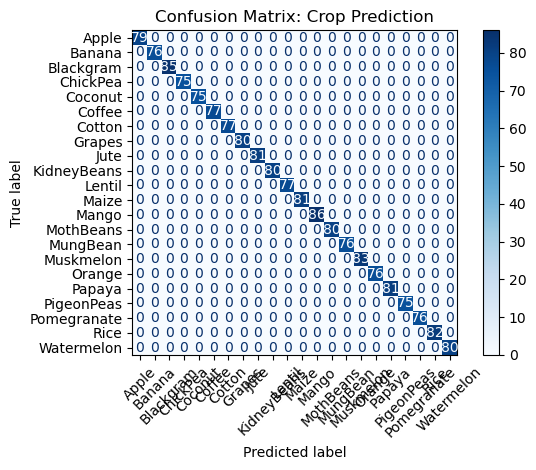

In [13]:



# Load the datasets
actual_df = pd.read_csv('train_dataset.csv')
predicted_df = pd.read_csv('predicted_train_crops_output.csv')

# Make sure columns are aligned (assuming 'crop' is the label column)
y_true = actual_df['Crop']
y_pred = predicted_df['Predicted_Crop']

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix: Crop Prediction")
plt.tight_layout()
plt.show()


In [14]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('test_dataset_without_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_test_crops_output.csv', index=False)


Predicted Crops:
ChickPea
Orange
Jute
MungBean
Coffee
Muskmelon
MothBeans
Maize
Papaya
MothBeans
Lentil
Rice
Muskmelon
Papaya
PigeonPeas
Apple
Cotton
Cotton
Pomegranate
Orange
Muskmelon
Cotton
Maize
Rice
Maize
Watermelon
Coconut
Orange
Maize
Coffee
Grapes
Lentil
Watermelon
Coconut
Maize
MothBeans
Lentil
Rice
Coconut
MungBean
Watermelon
Cotton
Watermelon
Blackgram
Coconut
PigeonPeas
MothBeans
Grapes
KidneyBeans
Maize
Muskmelon
Banana
Coconut
Apple
Orange
MungBean
Apple
MungBean
Apple
Muskmelon
KidneyBeans
Maize
Apple
Coconut
KidneyBeans
Lentil
Blackgram
Maize
Orange
KidneyBeans
ChickPea
Banana
Papaya
Papaya
Banana
MothBeans
Orange
Maize
ChickPea
Mango
ChickPea
Blackgram
Watermelon
Coconut
Coffee
Orange
PigeonPeas
Rice
Apple
Grapes
Jute
MungBean
Watermelon
Grapes
Watermelon
MothBeans
Pomegranate
MothBeans
PigeonPeas
Coffee
Rice
Coffee
Banana
Banana
Pomegranate
Papaya
KidneyBeans
Pomegranate
Grapes
Blackgram
Coffee
Banana
ChickPea
Cotton
Coffee
PigeonPeas
MothBeans
MothBeans
Orange
ChickP

In [15]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('test_dataset.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_test_crops_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


✅ Correct Predictions: 433
❌ Incorrect Predictions: 2
🎯 Accuracy: 99.54%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        47          79         78    17.483954  14.760145  6.609697   
1        24          30         11    32.395240  94.517685  6.601396   
2        78          46         42    23.094996  78.459597  7.095413   
3        34          45         21    28.188371  82.606297  6.287380   
4        99          15         27    27.042417  57.279275  6.501157   

     Rainfall      Crop Predicted_Crop  Correct  
0   65.113656  ChickPea       ChickPea     True  
1  113.253730    Orange         Orange     True  
2  155.385153      Jute           Jute     True  
3   37.011104  MungBean       MungBean     True  
4  165.687212    Coffee         Coffee     True  

Sample Incorrect Predictions:
     Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
269        99          41         36    24.458021  82.748356

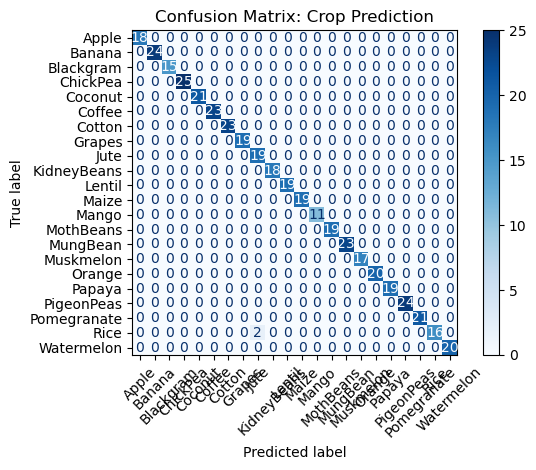

In [49]:


# Load the datasets
actual_df = pd.read_csv('test_dataset.csv')
predicted_df = pd.read_csv('predicted_test_crops_output.csv')

# Make sure columns are aligned (assuming 'crop' is the label column)
y_true = actual_df['Crop']
y_pred = predicted_df['Predicted_Crop']

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y_true.unique()))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix: Crop Prediction")
plt.tight_layout()
plt.show()


In [18]:


# Load the dataset
df = pd.read_csv('cleaned_dataset.csv')

# Separate features and labels
X = df.drop(columns=['Crop'])
y = df['Crop']

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create and save batches with proportional crop distribution
for i, (_, test_index) in enumerate(skf.split(X, y)):
    batch = df.iloc[test_index]
    batch.to_csv(f'crop_data_batch_{i+1}.csv', index=False)
    print(f"Batch {i+1} saved with {len(batch)} rows and class distribution:\n{batch['Crop'].value_counts()}\n")

Batch 1 saved with 435 rows and class distribution:
Crop
Rice           20
Banana         20
Jute           20
Cotton         20
Papaya         20
Apple          20
Muskmelon      20
Watermelon     20
Grapes         20
Maize          20
Coffee         20
Lentil         20
Blackgram      20
MothBeans      20
PigeonPeas     20
KidneyBeans    20
ChickPea       20
Pomegranate    19
MungBean       19
Orange         19
Coconut        19
Mango          19
Name: count, dtype: int64

Batch 2 saved with 435 rows and class distribution:
Crop
Rice           20
Banana         20
Jute           20
Cotton         20
Papaya         20
Orange         20
Muskmelon      20
Watermelon     20
Grapes         20
Maize          20
Coffee         20
Pomegranate    20
Blackgram      20
MungBean       20
PigeonPeas     20
KidneyBeans    20
ChickPea       20
Lentil         19
Apple          19
MothBeans      19
Coconut        19
Mango          19
Name: count, dtype: int64

Batch 3 saved with 435 rows and class di

In [19]:

# Load the dataset
df = pd.read_csv('cleaned_dataset.csv')

# Separate features and target
X = df.drop(columns=['Crop'])
y = df['Crop']

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Split and save each batch
for i, (_, test_index) in enumerate(skf.split(X, y)):
    batch = df.iloc[test_index]
    batch.to_csv(f'crop_data_batch_{i+1}.csv', index=False)
    print(f"Saved crop_data_batch_{i+1}.csv with {len(batch)} rows")

Saved crop_data_batch_1.csv with 435 rows
Saved crop_data_batch_2.csv with 435 rows
Saved crop_data_batch_3.csv with 435 rows
Saved crop_data_batch_4.csv with 434 rows
Saved crop_data_batch_5.csv with 434 rows


In [44]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('crop_data_batch_1_no_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops of Batch 1:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_crops_batch1_output.csv', index=False)

Predicted Crops of Batch 1:
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
Mo

In [45]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('crop_data_batch_1.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_crops_batch1_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print("Batch 1 Accuracy")
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


Batch 1 Accuracy
✅ Correct Predictions: 435
❌ Incorrect Predictions: 0
🎯 Accuracy: 100.00%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        89          54         38    24.515881  83.535216  6.685346   
1        68          58         38    23.223974  83.033227  6.336254   
2        91          53         40    26.527235  81.417538  5.386168   
3        60          48         39    24.282094  80.300256  7.042299   
4        77          38         36    21.865252  80.192301  5.953933   

     Rainfall  Crop Predicted_Crop  Correct  
0  230.446236  Rice           Rice     True  
1  221.209196  Rice           Rice     True  
2  264.614870  Rice           Rice     True  
3  231.086335  Rice           Rice     True  
4  224.555017  Rice           Rice     True  

Sample Incorrect Predictions:
Empty DataFrame
Columns: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH_Value, Rainfall, Crop, Predicted_Crop, Correct]
Index: 

In [43]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('crop_data_batch_2_no_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops of Batch 2:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_crops_batch2_output.csv', index=False)

Predicted Crops of Batch 2:
Rice
Rice
Rice
Jute
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
Mo

In [41]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('crop_data_batch_2.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_crops_batch2_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print("Batch 2 Accuracy")
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


Batch 2 Accuracy
✅ Correct Predictions: 434
❌ Incorrect Predictions: 1
🎯 Accuracy: 99.77%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        69          37         42    23.058049  83.370118  7.073454   
1        69          55         38    22.708838  82.639414  5.700806   
2        90          46         42    23.978982  81.450616  7.502834   
4        88          35         40    23.579436  83.587603  5.853932   
5        67          59         41    21.947667  80.973842  6.012633   

     Rainfall  Crop Predicted_Crop  Correct  
0  251.055000  Rice           Rice     True  
1  271.324860  Rice           Rice     True  
2  250.083234  Rice           Rice     True  
4  291.298662  Rice           Rice     True  
5  213.356092  Rice           Rice     True  

Sample Incorrect Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
3        93          56         36    24.014976  82.056872  6.984354 

In [40]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('crop_data_batch_3_no_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops of Batch 3:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_crops_batch3_output.csv', index=False)

Predicted Crops of Batch 3:
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
Mot

In [39]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('crop_data_batch_3.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_crops_batch3_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print("Batch 3 Accuracy")
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


Batch 3 Accuracy
✅ Correct Predictions: 435
❌ Incorrect Predictions: 0
🎯 Accuracy: 100.00%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        85          58         41    21.770462  80.319644  7.038096   
1        74          35         40    26.491096  80.158363  6.980401   
2        78          42         42    20.130175  81.604873  7.628473   
3        89          45         36    21.325042  80.474764  6.442475   
4        83          41         43    21.052536  82.678395  6.254028   

     Rainfall  Crop Predicted_Crop  Correct  
0  226.655537  Rice           Rice     True  
1  242.864034  Rice           Rice     True  
2  262.717340  Rice           Rice     True  
3  185.497473  Rice           Rice     True  
4  233.107582  Rice           Rice     True  

Sample Incorrect Predictions:
Empty DataFrame
Columns: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH_Value, Rainfall, Crop, Predicted_Crop, Correct]
Index: 

In [38]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('crop_data_batch_4_no_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops of Batch 4:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_crops_batch4_output.csv', index=False)

Predicted Crops of Batch 4:
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Jute
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
Moth

In [37]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('crop_data_batch_4.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_crops_batch4_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print("Batch 4 Accuracy")
print(f"✅ Correct Predictions : {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


Batch 4 Accuracy
✅ Correct Predictions : 431
❌ Incorrect Predictions: 3
🎯 Accuracy: 99.31%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        60          55         44    23.004459  82.320763  7.840207   
1        78          58         44    26.800796  80.886848  5.108682   
2        85          38         41    21.587118  82.788371  6.249051   
3        91          35         39    23.793920  80.418180  6.970860   
4        98          47         37    23.483813  81.332651  7.375483   

     Rainfall  Crop Predicted_Crop  Correct  
0  263.964248  Rice           Rice     True  
1  284.436457  Rice           Rice     True  
2  276.655246  Rice           Rice     True  
3  206.261186  Rice           Rice     True  
4  224.058116  Rice           Rice     True  

Sample Incorrect Predictions:
     Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
256        11         124        204    13.429886  80.066340  6.36

In [36]:


# Load the trained model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Load the dataset without the 'Crop' column
input_df = pd.read_csv('crop_data_batch_5_no_crop.csv')

# Predict the crop values
predictions = model.predict(input_df)

# Decode label indices to crop names
predicted_crops = le.inverse_transform(predictions)

# Print each predicted crop
print("Predicted Crops of batch 5:")
for crop in predicted_crops:
    print(crop)

# Count and print each crop type
print("\nCrop Prediction Summary:")
crop_counts = pd.Series(predicted_crops).value_counts()
print(crop_counts)

# Print total number of predictions
total_predictions = len(predicted_crops)
print(f"\nTotal Predicted Crops: {total_predictions}")

# Add predictions to the DataFrame
input_df['Predicted_Crop'] = predicted_crops

# Save the updated DataFrame with predictions
input_df.to_csv('predicted_crops_batch5_output.csv', index=False)

Predicted Crops of batch 5:
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Rice
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
Maize
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
ChickPea
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
KidneyBeans
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
PigeonPeas
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
MothBeans
Moth

In [46]:


# Load original test dataset (with actual Crop values)
original_df = pd.read_csv('crop_data_batch_5.csv')

# Load predicted dataset (with Predicted_Crop column)
predicted_df = pd.read_csv('predicted_crops_batch5_output.csv')

# Combine actual and predicted crops into one DataFrame
comparison_df = original_df.copy()
comparison_df['Predicted_Crop'] = predicted_df['Predicted_Crop']

# Create a new column to flag correctness
comparison_df['Correct'] = comparison_df['Crop'] == comparison_df['Predicted_Crop']

# Count correct and incorrect predictions
correct_count = comparison_df['Correct'].sum()
incorrect_count = len(comparison_df) - correct_count
total = len(comparison_df)
accuracy = (correct_count / total) * 100

# Print the summary
print("Batch 5 Accuracy")
print(f"✅ Correct Predictions: {correct_count}")
print(f"❌ Incorrect Predictions: {incorrect_count}")
print(f"🎯 Accuracy: {accuracy:.2f}%")

# Optional: Show some correct and incorrect examples
print("\nSample Correct Predictions:")
print(comparison_df[comparison_df['Correct']].head())

print("\nSample Incorrect Predictions:")
print(comparison_df[~comparison_df['Correct']].head())


Batch 5 Accuracy
✅ Correct Predictions: 434
❌ Incorrect Predictions: 0
🎯 Accuracy: 100.00%

Sample Correct Predictions:
   Nitrogen  Phosphorus  Potassium  Temperature   Humidity  pH_Value  \
0        90          42         43    20.879744  82.002744  6.502985   
1        94          53         40    20.277744  82.894086  5.718627   
2        94          50         37    25.665852  80.663850  6.948020   
3        76          40         43    25.157455  83.117135  5.070176   
4        97          50         41    24.529227  80.544986  7.070960   

     Rainfall  Crop Predicted_Crop  Correct  
0  202.935536  Rice           Rice     True  
1  241.974195  Rice           Rice     True  
2  209.586971  Rice           Rice     True  
3  231.384316  Rice           Rice     True  
4  260.263403  Rice           Rice     True  

Sample Incorrect Predictions:
Empty DataFrame
Columns: [Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH_Value, Rainfall, Crop, Predicted_Crop, Correct]
Index: 

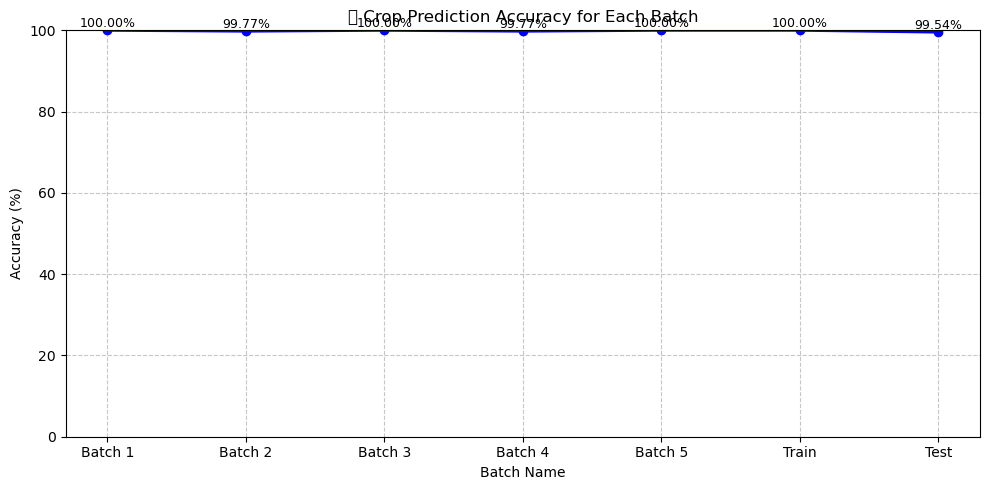

In [30]:

# Example data (replace with your actual values)
batch_names = ['Batch 1', 'Batch 2', 'Batch 3', 'Batch 4', 'Batch 5','Train','Test']
accuracies = [100.0,99.77,100.0,99.77,100.0,100.0,99.54]  # In percentage (not decimals)

# Create the line plot
plt.figure(figsize=(10, 5))
plt.plot(batch_names, accuracies, marker='o', linestyle='-', color='blue', linewidth=2)

# Add value labels on each point
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.05, f"{value:.2f}%", ha='center', va='bottom', fontsize=9)

# Labels and title
plt.xlabel("Batch Name")
plt.ylabel("Accuracy (%)")
plt.title("📈 Crop Prediction Accuracy for Each Batch")
plt.ylim(0, 100)  # Focus on the high-accuracy range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


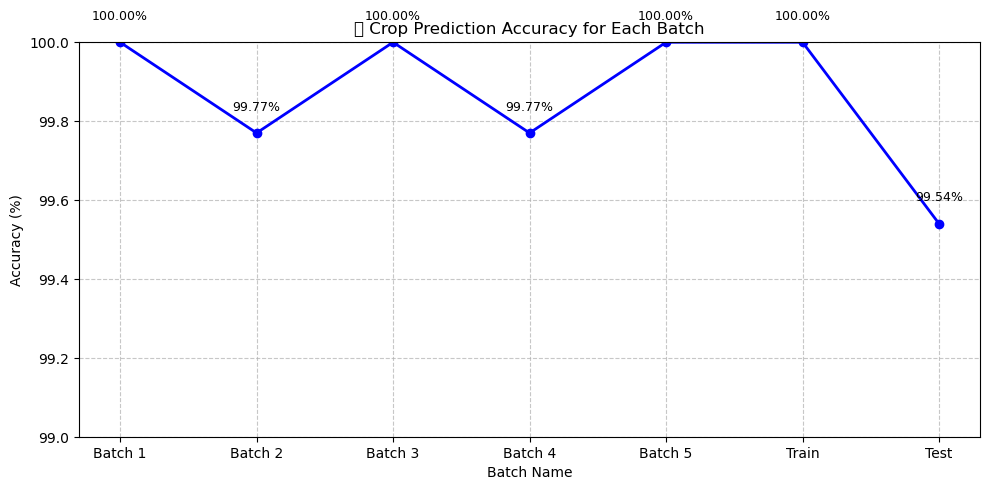

In [31]:


# Example data (replace with your actual values)
batch_names = ['Batch 1', 'Batch 2', 'Batch 3', 'Batch 4', 'Batch 5','Train','Test']
accuracies = [100.0,99.77,100.0,99.77,100.0,100.0,99.54]  # In percentage (not decimals)

# Create the line plot
plt.figure(figsize=(10, 5))
plt.plot(batch_names, accuracies, marker='o', linestyle='-', color='blue', linewidth=2)

# Add value labels on each point
for i, value in enumerate(accuracies):
    plt.text(i, value + 0.05, f"{value:.2f}%", ha='center', va='bottom', fontsize=9)

# Labels and title
plt.xlabel("Batch Name")
plt.ylabel("Accuracy (%)")
plt.title("📈 Crop Prediction Accuracy for Each Batch")
plt.ylim(99, 100)  # Focus on the high-accuracy range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()


In [32]:


# Load model and label encoder
model = joblib.load('random_forest_crop_model.pkl')
le = joblib.load('label_encoder.pkl')

# Define feature order
features = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']

# Take input in one line
user_input = input(f"Enter the values for {', '.join(features)} separated by commas:\n")

# Convert input string to list of floats
user_values = list(map(float, user_input.strip().split(',')))

# Create DataFrame
input_df = pd.DataFrame([user_values], columns=features)

# Predict
pred = model.predict(input_df)
crop = le.inverse_transform(pred)

print(f"\nRecommended Crop: {crop[0]}")


Enter the values for Nitrogen, Phosphorus, Potassium, Temperature, Humidity, pH_Value, Rainfall separated by commas:
 78,42,12,45,20.0,8,100



Recommended Crop: Maize
